<a href="https://colab.research.google.com/github/lakshmi-bhuvana/wine-quality-ml-project/blob/main/wine_quality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Wine Quality Prediction with Feature Scaling and Model Comparison**

---



Load The Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality (1).csv to winequality (1).csv


1. IMPORT LIBRARIES

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("Import Completed")

Import Completed


2. LOAD DATA

In [ ]:

df = pd.read_csv('winequality (1).csv')

print(df.head())
print(df.info())
print(df.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

3. CHECK MISSING VALUES

In [ ]:

print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


4. CORRELATION ANALYSIS

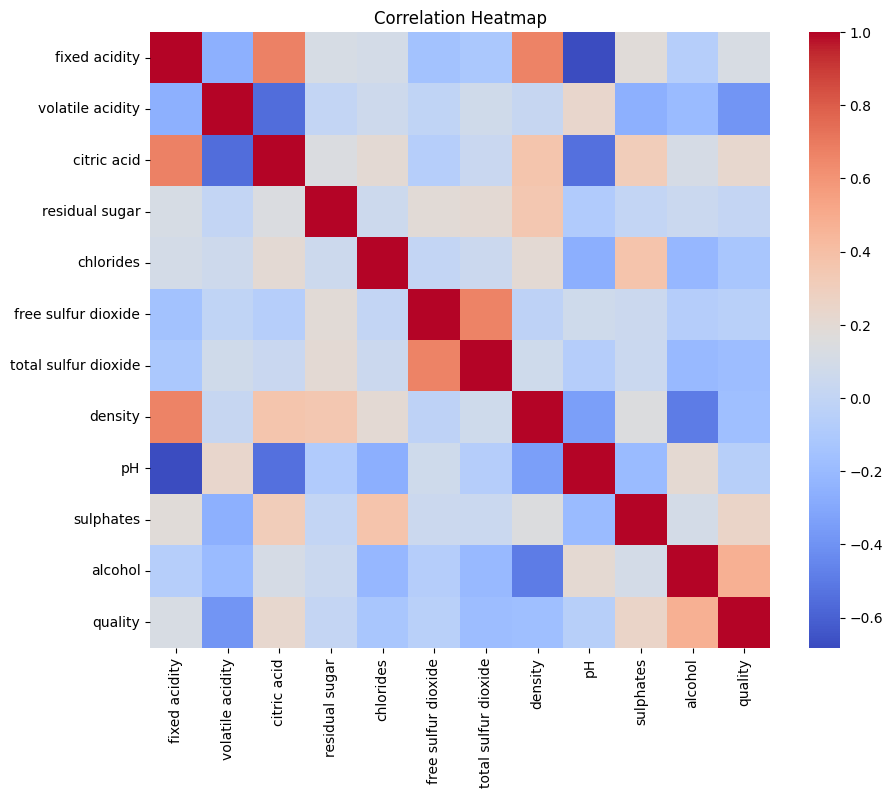

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

print(df.corr()['quality'].sort_values(ascending=False))

5. CREATE BINARY TARGET

In [ ]:

df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print(df['quality_label'].value_counts())

quality_label
0    1382
1     217
Name: count, dtype: int64


6. FEATURES & TARGET

In [ ]:

X = df.drop(['quality', 'quality_label'], axis=1).values   # NumPy
y = df['quality_label'].values

 7. TRAIN-TEST SPLIT

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8. LOGISTIC REGRESSION (NO SCALING)

In [ ]:

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\n--- Logistic Regression (No Scaling) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


--- Logistic Regression (No Scaling) ---
Accuracy: 0.859375
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       273
           1       0.55      0.23      0.33        47

    accuracy                           0.86       320
   macro avg       0.72      0.60      0.62       320
weighted avg       0.83      0.86      0.83       320

[[264   9]
 [ 36  11]]


9. FEATURE SCALING

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

10. LOGISTIC REGRESSION (WITH SCALING)

In [ ]:

lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("\n--- Logistic Regression (With Scaling) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))
print(confusion_matrix(y_test, y_pred_scaled))


--- Logistic Regression (With Scaling) ---
Accuracy: 0.865625
              precision    recall  f1-score   support

           0       0.89      0.97      0.92       273
           1       0.59      0.28      0.38        47

    accuracy                           0.87       320
   macro avg       0.74      0.62      0.65       320
weighted avg       0.84      0.87      0.84       320

[[264   9]
 [ 34  13]]


11. MODEL COMPARISON

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

print("\n--- Model Comparison ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name}: {accuracy_score(y_test, y_pred)}")



--- Model Comparison ---
Logistic Regression: 0.865625
KNN: 0.88125
Decision Tree: 0.8875


12. HYPERPARAMETER TUNING (KNN)

In [ ]:

param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'n_neighbors': 5, 'weights': 'distance'}


 13. FINAL MODEL EVALUATION

In [ ]:

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

print("\n--- Final Model ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


--- Final Model ---
Accuracy: 0.9125
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       273
           1       0.73      0.64      0.68        47

    accuracy                           0.91       320
   macro avg       0.84      0.80      0.82       320
weighted avg       0.91      0.91      0.91       320

[[262  11]
 [ 17  30]]


 14. FEATURE IMPORTANCE (Decision Tree)

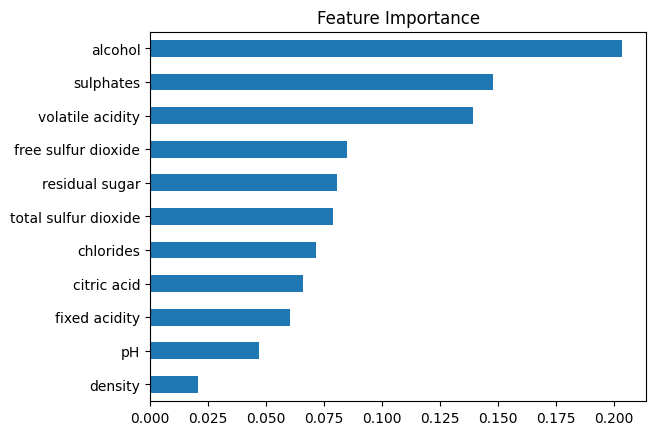

In [ ]:

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

importances = pd.Series(dt.feature_importances_,
                       index=df.drop(['quality','quality_label'], axis=1).columns)

importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()